# Stock Price Prediction using HMM
## Sagar Clemensen
### 24/3-2026
In this notebook, I will predict stock prices using  Hidden Markov Model (HMM). I will use different types of data to train the a model and compare the performance of each model using various error metrics.


In [16]:
# Import necessary libraries for data manipulation, model building, plotting, and evaluation


from Funcs import * 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import optuna
colors = ['#E63946','#3D8C40', "#ECA870", '#2A9D8F', '#7B2D8B', "#E583C8",  '#457B9D']
plt.rcParams['font.family'] = 'Georgia'
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16

## Load and Prepare Data

In this section, we load the data and preprocess it for modeling.


In [17]:
df_nvo = dataExtracterDays('NVO', '2016-01-01', '2026-01-01')
df_nvo
df_nvo = feature_prep(df_nvo)
df_nvo

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 2514 days


,Date,Open,High,Low,Close,Return,LogReturn,Volatility,Momentum
10,2016-01-19,21.714841,21.755293,21.391222,21.520670,0.001506,0.001505,0.018116,-0.024390
11,2016-01-20,21.172778,21.565166,20.857250,21.395266,-0.005827,-0.005844,0.016862,-0.045824
12,2016-01-21,21.613710,21.735067,21.346724,21.569212,0.008130,0.008097,0.017653,-0.014964
13,2016-01-22,21.917105,22.248814,21.900923,22.143639,0.026632,0.026283,0.019691,-0.004003
14,2016-01-25,22.289269,22.588617,22.204319,22.353992,0.009500,0.009455,0.018519,0.040286
...,...,...,...,...,...,...,...,...,...
2509,2025-12-24,52.849998,53.630001,52.000000,52.560001,0.018407,0.018240,0.028437,0.100272
2510,2025-12-26,53.020000,53.029999,51.700001,52.400002,-0.003044,-0.003049,0.027850,0.100609
2511,2025-12-29,51.560001,51.990002,51.349998,51.470001,-0.017748,-0.017907,0.028685,0.070285
2512,2025-12-30,51.520000,51.669998,51.070000,51.220001,-0.004857,-0.004869,0.028786,0.064865


In [18]:
df_SP = dataExtracterDays('^GSPC', '2022-01-01', '2024-01-01')
df_SP = feature_prep(df_SP)
tickers = ['LLY', 'PFE', 'MRK', 'JNJ', 'SNY', 'AZN']
df_list = []
for ticker in tickers:
    df = dataExtracterDays(ticker, '2022-01-01', '2024-01-01')
    df = feature_prep(df)
    df_list.append(df)
df_nvo = dataExtracterDays('NVO', '2022-01-01', '2026-01-01')
df_nvo = feature_prep(df_nvo)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


The dataset has observations across 501 days
The dataset has observations across 501 days
The dataset has observations across 501 days
The dataset has observations across 501 days
The dataset has observations across 501 days


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


The dataset has observations across 501 days
The dataset has observations across 501 days


[*********************100%***********************]  1 of 1 completed

The dataset has observations across 1003 days


## Train HMM model on different data types

In [19]:
Ntrain = len(df_SP)
print("Training size:", Ntrain)
Nwindow = 30
NStates = 7

NVO_pred, obs_price, exp_returns = HMM_predict(df_nvo, train_size=Ntrain, window_size=Nwindow, Ncomp=NStates, doprint=False)
NVO_pred_SP, _, _ = HMM_predict_other(df_SP, df_nvo[Ntrain-Nwindow:], window_size=Nwindow, Ncomp=NStates, doprint=False)
NVO_pred_pharm, _, _ = HMM_predict_multi(df_list, df_nvo[Ntrain-Nwindow:], window_size=Nwindow, Ncomp=NStates, doprint=False)

Training size: 491
Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02
Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02
Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02


## Plot Predictions

Now, we plot the predictions from all models alongside the actual observed prices.


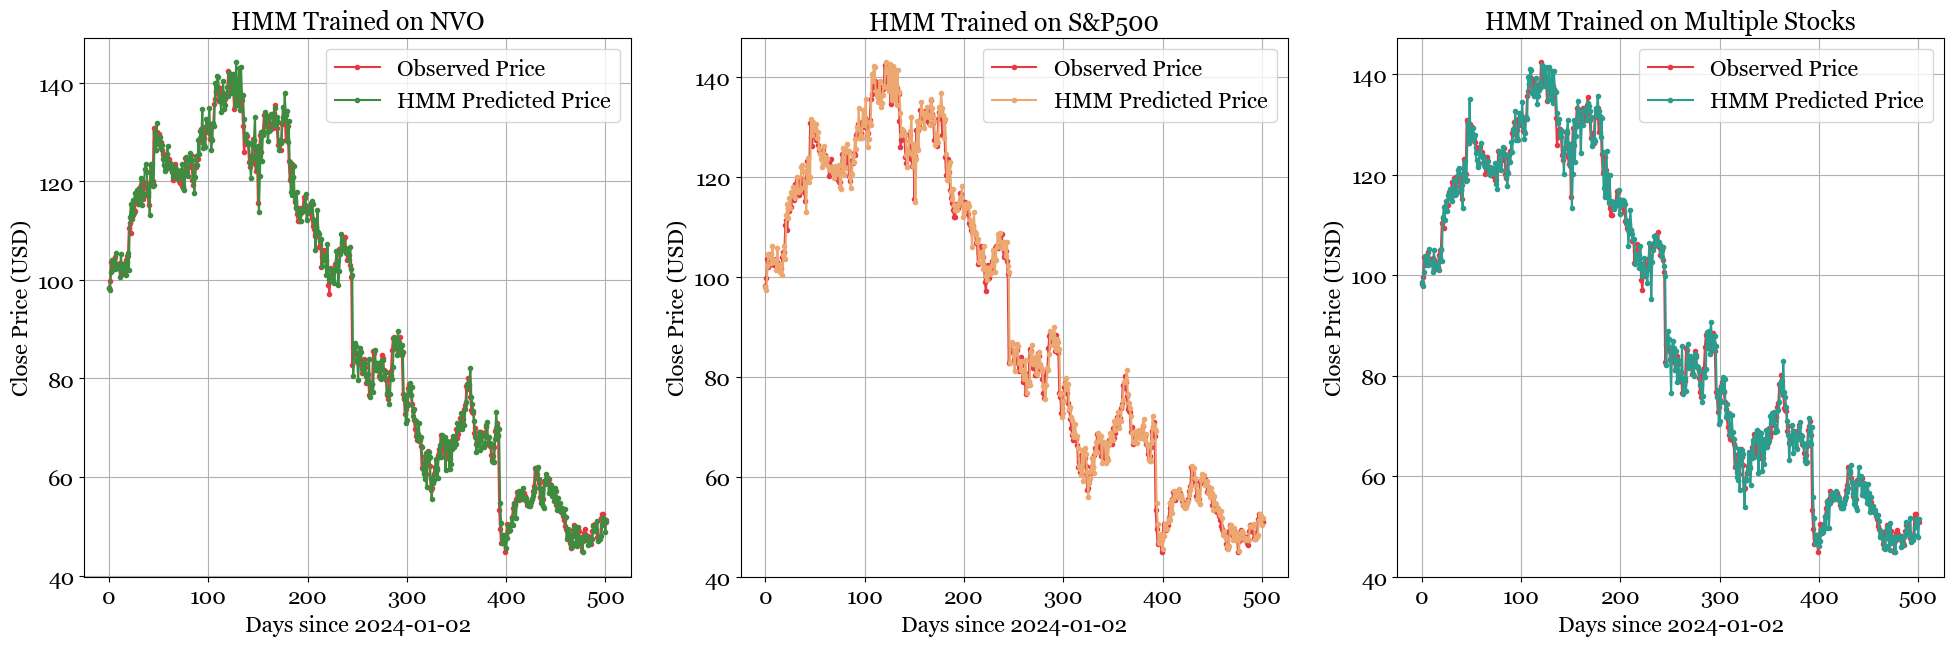

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(24, 7))
ax = axs.flatten()
# Plot actual prices for the corresponding period
predictions = [NVO_pred, NVO_pred_SP, NVO_pred_pharm]
titles = ['HMM Trained on NVO', 'HMM Trained on S&P500', 'HMM Trained on Multiple Stocks']
for i in range(3):
    ax[i].plot(obs_price, marker='.', label='Observed Price', color=colors[0])
    ax[i].plot(predictions[i], marker='.', label='HMM Predicted Price', color=colors[i+1])
    ax[i].set_ylabel("Close Price (USD)")
    ax[i].set_xlabel(f"Days since {df_nvo['Date'].iloc[Ntrain]}")
    ax[i].legend(loc='upper right')
    ax[i].set_title(titles[i])
    ax[i].grid()

Date for first day of plotted data: 2025-08-11


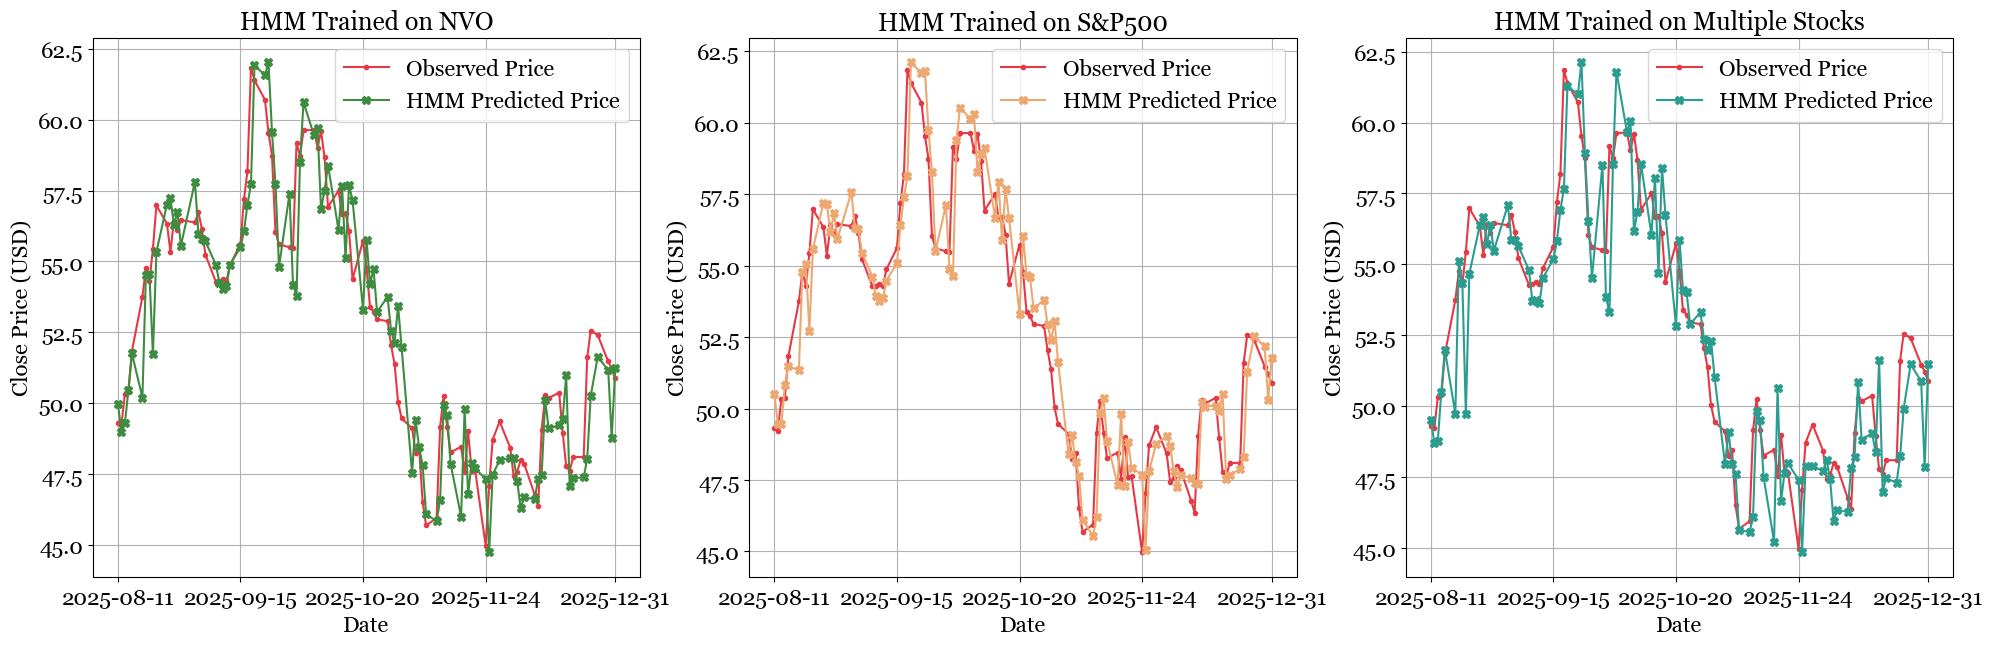

In [21]:
# Extract last 100 dates
dates = df_nvo['Date'].iloc[-100:]
begin_date = dates.iloc[0].strftime('%Y-%m-%d')
print(f"Date for first day of plotted data: {begin_date}")

fig, axs = plt.subplots(1, 3, figsize=(24, 7))
ax = axs.flatten()
predictions = [NVO_pred, NVO_pred_SP, NVO_pred_pharm]
titles = ['HMM Trained on NVO', 'HMM Trained on S&P500', 'HMM Trained on Multiple Stocks']
num_ticks = 5
tick_idx = np.linspace(0, len(dates) - 1, num_ticks, dtype=int)
for i in range(3):
    ax[i].plot(dates, obs_price[-100:], marker='.', label='Observed Price', color=colors[0])
    ax[i].plot(dates, predictions[i][-100:], marker='X', label='HMM Predicted Price', color=colors[1+i])
    ax[i].set_ylabel("Close Price (USD)")
    ax[i].set_xlabel("Date")
    ax[i].legend(loc='upper right')
    ax[i].set_title(titles[i])
    ax[i].grid()
    ax[i].set_xticks(dates.iloc[tick_idx])


## Model evaluation

Finally, we will evaluate the performance of each model using metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Direction Accuracy.

In [22]:
# Convert lists to numpy arrays
realPrices = [obs_price, obs_price, obs_price]
predictions = [NVO_pred, NVO_pred_SP, NVO_pred_pharm]
modelNames = ['Trained on NVO', 'Trained on SPY500', 'Trained on Multiple Stocks']

for i, (obs, pred) in enumerate(zip(realPrices, predictions)):
    mape_hmm = mape(obs[-100:], pred[-100:])
    print(len(obs))
    rmse_hmm = rmse(obs, pred)
    direction_accuracy_hmm = direction_accuracy(obs, pred)
    print(f"Evaluation Metrics for HMM {modelNames[i]}:")
    print(f"Mean Absolute Percentage Error:", mape_hmm)
    print(f"Root Mean Squared Error:", rmse_hmm)
    print(f"Direction Accuracy: ", direction_accuracy_hmm)
    print(f"Evaluation Metrics sum:", mape_hmm + rmse_hmm - direction_accuracy_hmm, "\n")

502
Evaluation Metrics for HMM Trained on NVO:
Mean Absolute Percentage Error: 0.022707101842560033
Root Mean Squared Error: 2.9475027479069333
Direction Accuracy:  0.47704590818363274
Evaluation Metrics sum: 2.493163941565861 

502
Evaluation Metrics for HMM Trained on SPY500:
Mean Absolute Percentage Error: 0.020458249124453293
Root Mean Squared Error: 2.7302739672540666
Direction Accuracy:  0.48303393213572854
Evaluation Metrics sum: 2.2676982842427913 

502
Evaluation Metrics for HMM Trained on Multiple Stocks:
Mean Absolute Percentage Error: 0.02469201426371284
Root Mean Squared Error: 3.047778730629629
Direction Accuracy:  0.4930139720558882
Evaluation Metrics sum: 2.5794567728374536 



## Optimization
Optimization of hyperparameters (training windows and hidden states) using Optuna.

In [23]:
def evaluate_params(df, Ntrain, Nwindow, NStates):
    real, pred, _ = HMM_predict(
        df,
        train_size=Ntrain,
        window_size=Nwindow,
        Ncomp=NStates
    )
    
    m = mape(real, pred)
    r = rmse(real, pred)
    d = direction_accuracy(real, pred)
    print(f"MAPE: {m}, RMSE: {r}, Direction Accuracy: {d}")

In [24]:
def objective(trial):
    Nwindow = trial.suggest_int("Nwindow", 15, 50)
    NStates = trial.suggest_int("NStates", 4, 8)
    
    real, pred, _ = HMM_predict(
        df_nvo,
        train_size=491,
        window_size=Nwindow,
        Ncomp=NStates
    )
    
    return mape(real, pred) + rmse(real, pred) - 2*direction_accuracy(real, pred)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print(study.best_params)

[I 2026-03-28 15:12:50,343] A new study created in memory with name: no-name-794a4bf1-32e8-4a49-bce6-dc685b454637


Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02


[I 2026-03-28 15:12:50,589] Trial 0 finished with value: 2.416613777917681 and parameters: {'Nwindow': 19, 'NStates': 4}. Best is trial 0 with value: 2.416613777917681.


Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02


[I 2026-03-28 15:12:50,844] Trial 1 finished with value: 2.1310742528429585 and parameters: {'Nwindow': 18, 'NStates': 8}. Best is trial 1 with value: 2.1310742528429585.


...

[I 2026-03-28 15:12:52,355] Trial 7 finished with value: 2.416613777917681 and parameters: {'Nwindow': 31, 'NStates': 4}. Best is trial 3 with value: 2.0174031395465106.


Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02


[I 2026-03-28 15:12:52,590] Trial 8 finished with value: 2.174939631198486 and parameters: {'Nwindow': 42, 'NStates': 6}. Best is trial 3 with value: 2.0174031395465106.
[W 2026-03-28 15:12:52,667] Trial 9 failed with parameters: {'Nwindow': 38, 'NStates': 4} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/sagar1/opt/anaconda3/envs/Pydev/lib/python3.13/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/q_/7x2w9vl95gjddqnzc20k_7sr0000gp/T/ipykernel_3084/2433752001.py", line 5, in objective
    real, pred, _ = HMM_predict(
                    ~~~~~~~~~~~^
        df_nvo,
        ^^^^^^^
    ...<2 lines>...
        Ncomp=NStates
        ^^^^^^^^^^^^^
    )
    ^
  File "/Users/sagar1/Desktop/Github/AMAS/Project/Funcs.py", line 83, in HMM_predict
    current_state = model.predict(window_scaled)[-1]
                    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^
  File "/Users/sagar

Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02


KeyboardInterrupt: 

In [ ]:
evaluate_params(df_nvo, 491, study.best_params["Nwindow"], study.best_params["NStates"])

Date for day before first prediction: 2023-12-29
Date for first day of real data: 2024-01-02
MAPE: 0.02399220800684265, RMSE: 2.9475027479069333, Direction Accuracy: 0.47704590818363274
